# Phase 4: Modeling - Leakage-Safe Workflow

This phase rebuilds the modeling workflow from raw telemetry instead of relying on the fully prepared CSV. The final validation is stricter:

- split by `car_id`, so test vehicles are not also present in training;
- fit preprocessing inside the model pipeline;
- apply ADASYN inside the `imblearn` pipeline and inside CV folds;
- select models using macro metrics instead of accuracy alone.

References: [scikit-learn data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage), [imbalanced-learn leakage pitfalls](https://imbalanced-learn.org/stable/common_pitfalls.html), [StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html).


---
## Section 1: Setup and Data Loading


In [1]:
%pip install -r requirements.txt

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached notebook-7.6.0-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab-4.6.1-py3-none-any.whl.metadata (16 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
  Using cached async_lru-2.3.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jupyter_lsp-2.3.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyter_server-2.20.0-py3-none-any.whl

In [2]:
import os
import sys
import json
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold

for path in [os.getcwd(), os.path.join(os.getcwd(), 'notebooks')]:
    if path not in sys.path:
        sys.path.append(path)

from leakage_safe_pipeline import (
    RANDOM_STATE, N_SPLITS, FINAL_FEATURES,
    load_dataset, first_group_holdout, candidate_models, make_pipeline,
    evaluate_predictions, param_grids,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')
%matplotlib inline

print('Phase 4: Leakage-safe modeling')
print(f'Start time: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')


Phase 4: Leakage-safe modeling
Start time: 2026-07-16 22:57:04


In [3]:
candidate_paths = [
    os.path.join('..', 'data', 'raw', 'fleet_augmented.csv'),
    os.path.join('data', 'raw', 'fleet_augmented.csv'),
]
RAW_DATA_PATH = next(path for path in candidate_paths if os.path.exists(path))

bundle = load_dataset(RAW_DATA_PATH)
split = first_group_holdout(bundle)

X_train = split['X_train']
X_test = split['X_test']
y_train = split['y_train']
y_test = split['y_test']
groups_train = split['groups_train']
groups_test = split['groups_test']

print(f'Raw shape: {bundle.raw_df.shape}')
print(f'Unique vehicles: {bundle.groups.nunique()}')
print('Label mapping:', bundle.label_mapping)
print(f'Train rows: {len(X_train):,} | Test rows: {len(X_test):,}')
print(f'Train vehicles: {groups_train.nunique():,} | Test vehicles: {groups_test.nunique():,}')
print(f'Vehicle overlap: {len(set(groups_train) & set(groups_test))}')

class_report = pd.DataFrame({
    'train_count': y_train.map(bundle.label_mapping_inv).value_counts().reindex(bundle.class_names, fill_value=0),
    'test_count': y_test.map(bundle.label_mapping_inv).value_counts().reindex(bundle.class_names, fill_value=0),
})
class_report['train_pct'] = (class_report['train_count'] / class_report['train_count'].sum() * 100).round(3)
class_report['test_pct'] = (class_report['test_count'] / class_report['test_count'].sum() * 100).round(3)
display(class_report)

assert len(set(groups_train) & set(groups_test)) == 0, 'Group leakage: a vehicle appears in both train and test.'


Raw shape: (20300, 13)
Unique vehicles: 500
Label mapping: {'Critical_Overheating': 0, 'Mechanical_Stress': 1, 'Normal': 2, 'Thermal_Overload': 3, 'Voltage_Sag': 4}
Train rows: 16,241 | Test rows: 4,059
Train vehicles: 401 | Test vehicles: 99
Vehicle overlap: 0


,train_count,test_count,train_pct,test_pct
failure_type,,,,
Critical_Overheating,280,64,1.7240,1.5770
Mechanical_Stress,40,10,0.2460,0.2460
Normal,15641,3913,96.3060,96.4030
Thermal_Overload,246,62,1.5150,1.5270
Voltage_Sag,34,10,0.2090,0.2460


---
## Section 2: Candidate Pipelines

Each candidate pipeline is:

`TelemetryFeatureTransformer -> StandardScaler -> ADASYN -> classifier`

The transformer and ADASYN are fitted only during training. The test set remains original and non-resampled.


In [4]:
pipelines = {
    name: make_pipeline(model)
    for name, model in candidate_models().items()
}

results = {}
for name, pipe in pipelines.items():
    print(f'\nTraining: {name}')
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    metrics = evaluate_predictions(y_test, y_pred)
    results[name] = {'pipeline': pipe, 'y_pred': y_pred, **metrics}
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  Balanced Accuracy: {metrics['Balanced Accuracy']:.4f}")
    print(f"  Macro F1: {metrics['Macro F1']:.4f}")



Training: Logistic Regression
  Accuracy: 0.9305
  Balanced Accuracy: 0.8210
  Macro F1: 0.5536

Training: Random Forest
  Accuracy: 0.9872
  Balanced Accuracy: 0.7406
  Macro F1: 0.7704

Training: SVC (RBF)
  Accuracy: 0.9712
  Balanced Accuracy: 0.7681
  Macro F1: 0.6362

Training: k-NN
  Accuracy: 0.9554
  Balanced Accuracy: 0.7694
  Macro F1: 0.5824

Training: XGBoost
  Accuracy: 0.9904
  Balanced Accuracy: 0.9102
  Macro F1: 0.8740

Training: LightGBM
  Accuracy: 0.9919
  Balanced Accuracy: 0.9105
  Macro F1: 0.8809


---
## Section 3: Model Comparison

Macro F1 and macro recall are the primary selection metrics because the rare failure classes matter more than the dominant `Normal` class.


,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
LightGBM,0.9919,0.9105,0.8569,0.9105,0.8809,0.9922
XGBoost,0.9904,0.9102,0.8460,0.9102,0.8740,0.9909
Random Forest,0.9872,0.7406,0.8478,0.7406,0.7704,0.9874
SVC (RBF),0.9712,0.7681,0.5738,0.7681,0.6362,0.9757
k-NN,0.9554,0.7694,0.5222,0.7694,0.5824,0.9654
Logistic Regression,0.9305,0.8210,0.4920,0.8210,0.5536,0.9510


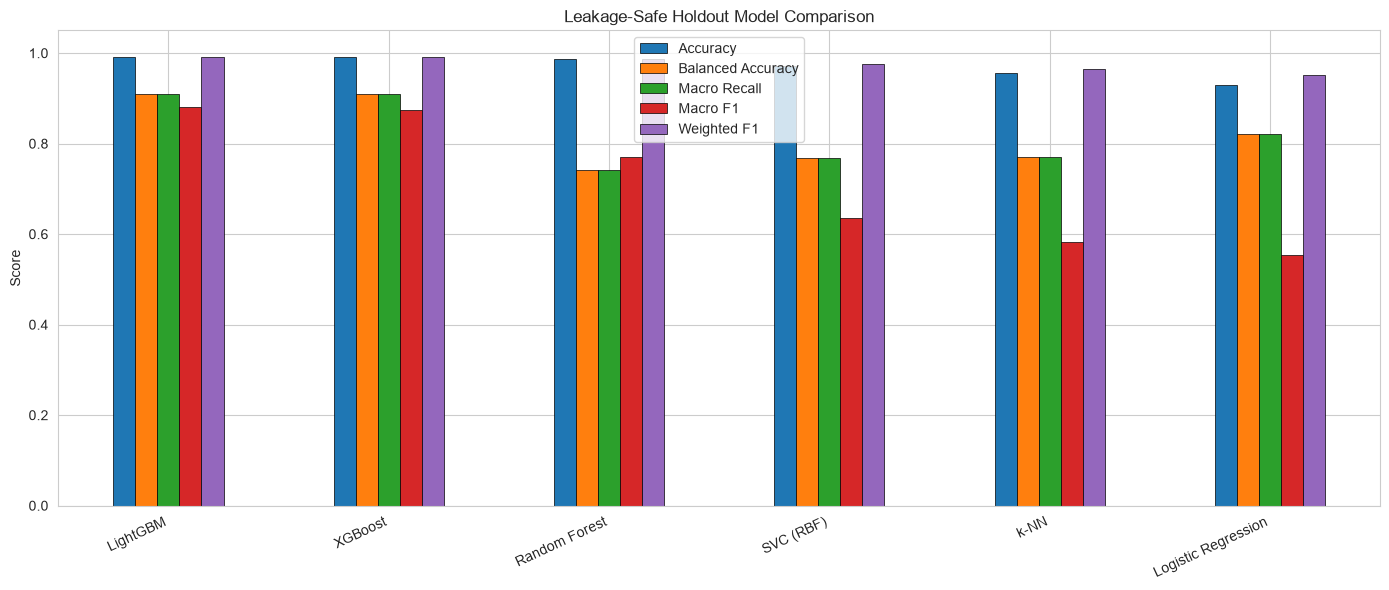

Best holdout model by Macro F1: LightGBM


In [5]:
comparison_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ['pipeline', 'y_pred']}
    for name, res in results.items()
}).T.sort_values('Macro F1', ascending=False)

display(comparison_df.style.format('{:.4f}').highlight_max(axis=0, color='lightgreen'))

fig, ax = plt.subplots(figsize=(14, 6))
comparison_df[['Accuracy', 'Balanced Accuracy', 'Macro Recall', 'Macro F1', 'Weighted F1']].plot(
    kind='bar', ax=ax, edgecolor='black', linewidth=0.5
)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Leakage-Safe Holdout Model Comparison')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

best_model_name = comparison_df['Macro F1'].idxmax()
best_pipeline = results[best_model_name]['pipeline']
y_pred_best = results[best_model_name]['y_pred']
print(f'Best holdout model by Macro F1: {best_model_name}')


                      precision    recall  f1-score   support

Critical_Overheating     0.7532    0.9062    0.8227        64
   Mechanical_Stress     0.7500    0.9000    0.8182        10
              Normal     0.9979    0.9946    0.9963      3913
    Thermal_Overload     0.9833    0.9516    0.9672        62
         Voltage_Sag     0.8000    0.8000    0.8000        10

            accuracy                         0.9919      4059
           macro avg     0.8569    0.9105    0.8809      4059
        weighted avg     0.9928    0.9919    0.9922      4059



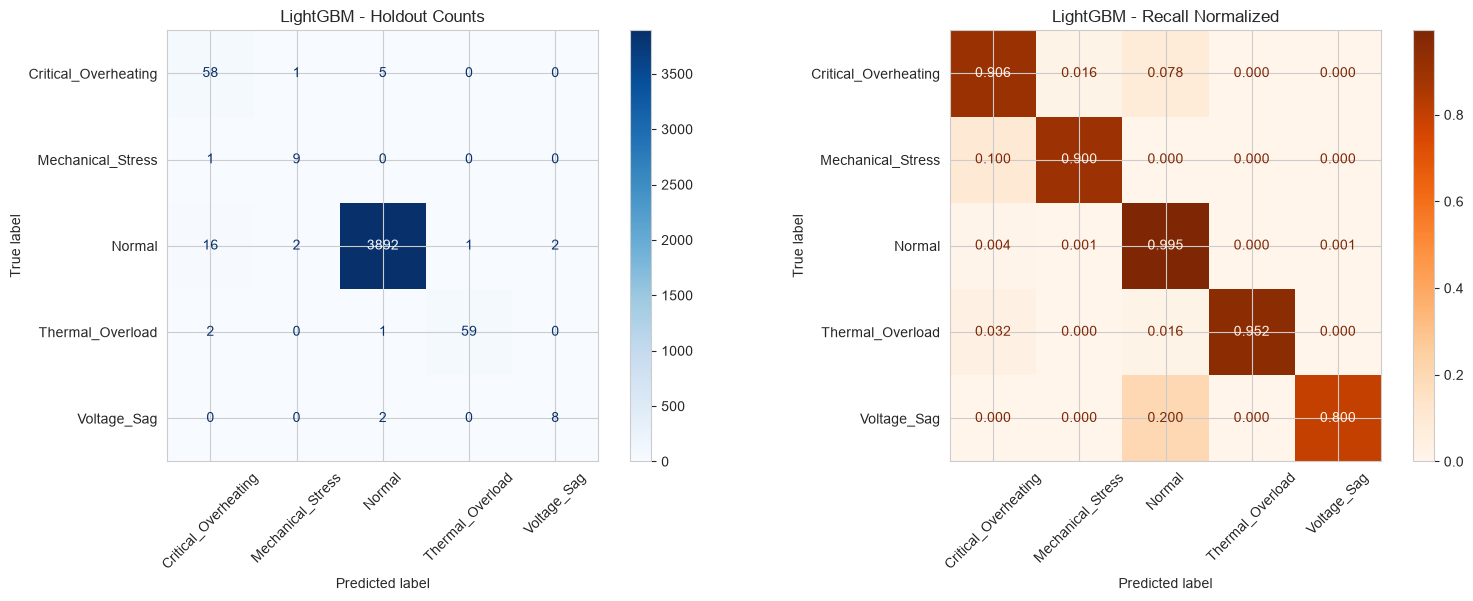

In [6]:
print(classification_report(y_test, y_pred_best, target_names=bundle.class_names, zero_division=0, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=bundle.class_names).plot(
    ax=axes[0], cmap='Blues', values_format='d', xticks_rotation=45
)
axes[0].set_title(f'{best_model_name} - Holdout Counts')

cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=bundle.class_names).plot(
    ax=axes[1], cmap='Oranges', values_format='.3f', xticks_rotation=45
)
axes[1].set_title(f'{best_model_name} - Recall Normalized')
plt.tight_layout()
plt.show()


---
## Section 4: Hyperparameter Tuning

Grid search is run on the full pipeline. Preprocessing, scaling, and ADASYN are refit inside each CV training fold, and `StratifiedGroupKFold` keeps vehicles isolated between training and validation.


In [7]:
selected_grid = param_grids()[best_model_name]
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=best_pipeline,
    param_grid=selected_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

print(f'Running leakage-safe GridSearchCV for: {best_model_name}')
grid_search.fit(X_train, y_train, groups=groups_train)
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV Macro F1: {grid_search.best_score_:.4f}')


Running leakage-safe GridSearchCV for: LightGBM
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 300, 'model__num_leaves': 31}
Best CV Macro F1: 0.9035


In [8]:
tuned_pipeline = grid_search.best_estimator_
y_pred_tuned = tuned_pipeline.predict(X_test)
tuned_metrics = evaluate_predictions(y_test, y_pred_tuned)

display(pd.DataFrame([tuned_metrics], index=[f'Tuned {best_model_name}']).style.format('{:.4f}'))
print(classification_report(y_test, y_pred_tuned, target_names=bundle.class_names, zero_division=0, digits=4))


,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Tuned LightGBM,0.9914,0.8904,0.8641,0.8904,0.8748,0.9917


                      precision    recall  f1-score   support

Critical_Overheating     0.7436    0.9062    0.8169        64
   Mechanical_Stress     0.8182    0.9000    0.8571        10
              Normal     0.9974    0.9944    0.9959      3913
    Thermal_Overload     0.9833    0.9516    0.9672        62
         Voltage_Sag     0.7778    0.7000    0.7368        10

            accuracy                         0.9914      4059
           macro avg     0.8641    0.8904    0.8748      4059
        weighted avg     0.9922    0.9914    0.9917      4059



---
## Section 5: Modeling Summary

The final project claim should use the tuned holdout metrics from this leakage-safe workflow. Do not reuse earlier random-row-split metrics as deployment evidence.


In [9]:
summary = {
    'split_strategy': 'StratifiedGroupKFold holdout by car_id',
    'vehicle_overlap_between_train_test': int(len(set(groups_train) & set(groups_test))),
    'best_model_before_tuning': best_model_name,
    'best_cv_macro_f1': float(grid_search.best_score_),
    'holdout_metrics_after_tuning': {k: float(v) for k, v in tuned_metrics.items()},
    'label_mapping': bundle.label_mapping,
    'feature_count': len(FINAL_FEATURES),
    'methodology_notes': [
        'Preprocessing is fitted inside the pipeline.',
        'ADASYN is fitted only inside training folds.',
        'Test vehicles are unseen during training.',
        'Accuracy is reported but not used as the primary success metric.'
    ],
}

print(json.dumps(summary, indent=2))


{
  "split_strategy": "StratifiedGroupKFold holdout by car_id",
  "vehicle_overlap_between_train_test": 0,
  "best_model_before_tuning": "LightGBM",
  "best_cv_macro_f1": 0.9034554371484795,
  "holdout_metrics_after_tuning": {
    "Accuracy": 0.9913771864991378,
    "Balanced Accuracy": 0.8904481237067507,
    "Macro Precision": 0.864063845522446,
    "Macro Recall": 0.8904481237067507,
    "Macro F1": 0.8748008543783703,
    "Weighted F1": 0.9916640013789961
  },
  "label_mapping": {
    "Critical_Overheating": 0,
    "Mechanical_Stress": 1,
    "Normal": 2,
    "Thermal_Overload": 3,
    "Voltage_Sag": 4
  },
  "feature_count": 25,
  "methodology_notes": [
    "Preprocessing is fitted inside the pipeline.",
    "ADASYN is fitted only inside training folds.",
    "Test vehicles are unseen during training.",
    "Accuracy is reported but not used as the primary success metric."
  ]
}
